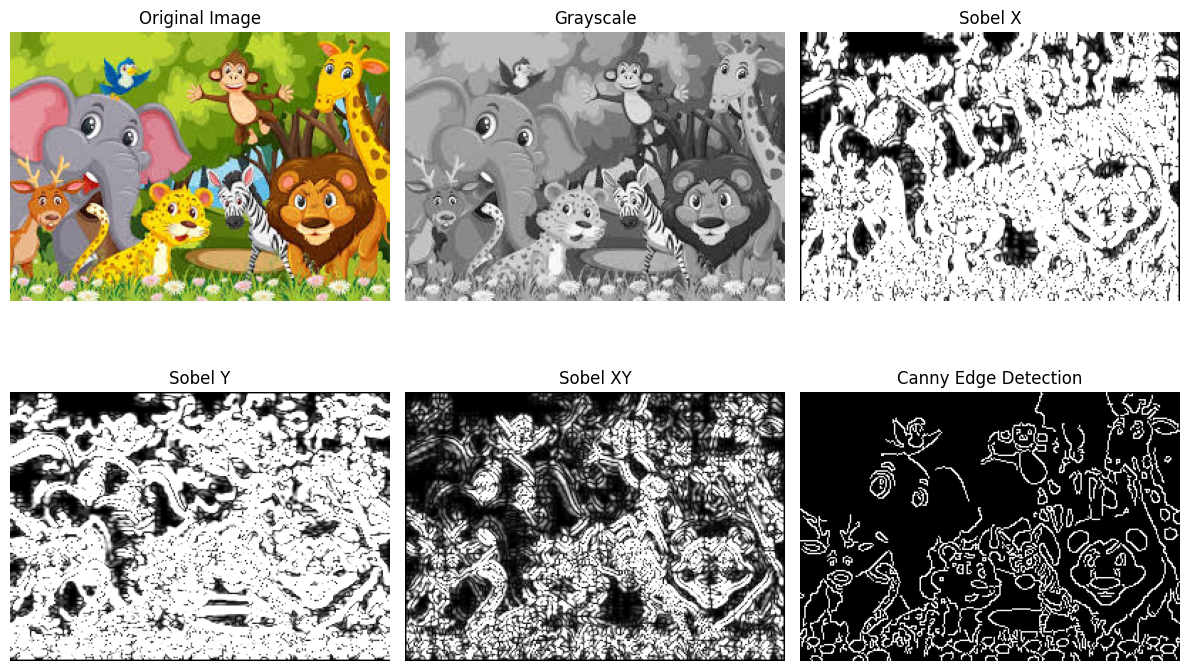

In [1]:
import cv2
import matplotlib.pyplot as plt

# Read the image
img = cv2.imread("Animals.jpg")
if img is None:
    print("Image not found")
    exit()

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Blur the image
blur = cv2.GaussianBlur(gray, (3,3), 0)

# -------- Sobel Edge Detection --------
sobelx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=5)
sobelxy = cv2.Sobel(blur, cv2.CV_64F, 1, 1, ksize=5)

# Convert to uint8 (IMPORTANT)
sobelx = cv2.convertScaleAbs(sobelx)
sobely = cv2.convertScaleAbs(sobely)
sobelxy = cv2.convertScaleAbs(sobelxy)

# -------- Canny Edge Detection --------
edges = cv2.Canny(blur, 100, 200)

# -------- Display Results --------
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(sobelxy, cmap='gray')
plt.title("Sobel XY")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")

plt.tight_layout()
plt.show()

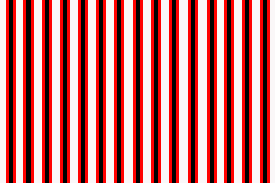

In [3]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Read image
img = cv2.imread('linedimage.png')

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Edge detection
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# Hough Line Transform
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)

# Check if lines are detected
if lines is not None:
    for line in lines:
        rho, theta = line[0]

        a = np.cos(theta)
        b = np.sin(theta)

        x0 = a * rho
        y0 = b * rho

        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
else:
    print("No lines were detected")

# Show output
cv2_imshow(img)

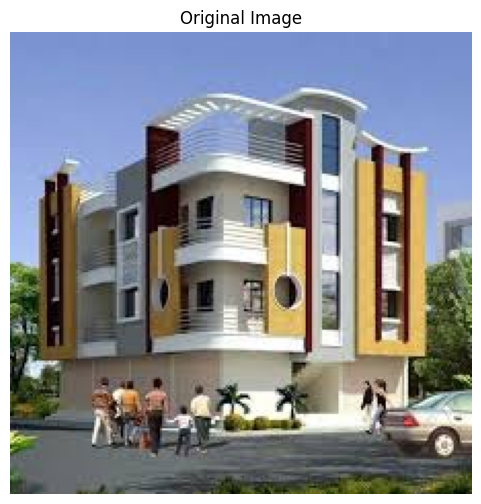

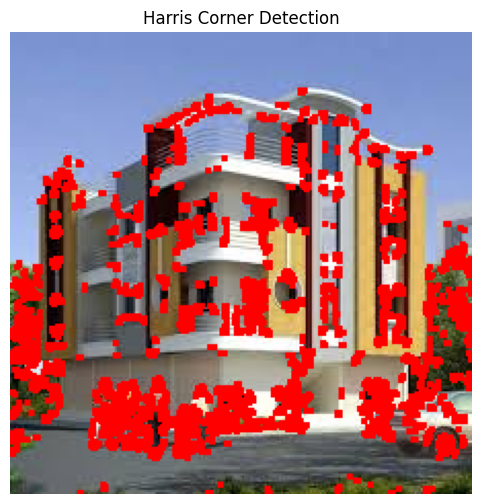

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("building.jpg")

# Convert BGR to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show original image
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Convert to float32
gray = np.float32(gray)

# Apply Harris Corner Detection
harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Dilate for better visibility
harris = cv2.dilate(harris, None)

# Copy image to draw corners
corner_img = image.copy()

# Mark corners (LOWER threshold = more corners)
corner_img[harris > 0.001 * harris.max()] = [0, 0, 255]

# Convert result to RGB
corner_img_rgb = cv2.cvtColor(corner_img, cv2.COLOR_BGR2RGB)

# Show Harris corner detection result
plt.figure(figsize=(6,6))
plt.imshow(corner_img_rgb)
plt.title("Harris Corner Detection")
plt.axis("off")
plt.show()